# H&M Personalized Fashion Recommendations
## GPU 加速版：PyTorch SVD + 4 路召回 + LightGBM/CatBoost 排序

**Kaggle 竞赛**：https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations  
**评价指标**：MAP@12  
**方案来源**：README.md（rank: 116/2952）  
**GPU 加速**：PyTorch SVD (P100) → LightGBM GPU → CatBoost GPU

In [1]:
!pip install lightfm
# ============================================
# Cell 1: 环境配置与导入（GPU 加速版）
# ============================================
import numpy as np
import pandas as pd
import os, gc, warnings, sys
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix, coo_matrix
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

# PyTorch GPU
import torch
if torch.cuda.is_available():
    print(f'GPU 可用：{torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
else:
    print('未检测到 GPU，将使用 CPU')
    device = torch.device('cpu')

print(f'Python 版本: {sys.version}')
print(f'Pandas: {pd.__version__}, NumPy: {np.__version__}')
print(f'PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}')
print(f'LightGBM: {lgb.__version__}')

# 自动检测 Kaggle 输入路径
if os.path.exists('/kaggle/input/h-and-m-personalized-fashion-recommendations/'):
    DATA_DIR = '/kaggle/input/h-and-m-personalized-fashion-recommendations/'
elif os.path.exists('/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/'):
    DATA_DIR = '/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/'
else:
    # 尝试自动发现
    input_dir = '/kaggle/input/'
    candidates = [d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))] if os.path.exists(input_dir) else []
    if candidates:
        DATA_DIR = os.path.join(input_dir, candidates[0]) + '/'
        print(f'自动检测到输入路径: {DATA_DIR}')
    else:
        raise FileNotFoundError('未找到 H&M 数据输入路径，请确认已在 Notebook 中添加竞赛数据')

SEED = 42
np.random.seed(SEED)

GPU 可用：Tesla P100-PCIE-16GB
Python 版本: 3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 06:08:53) 
[GCC 9.4.0]
Pandas: 1.3.5, NumPy: 1.21.6
PyTorch: 1.11.0, CUDA: 11.0
LightGBM: 3.3.2


In [2]:
# ============================================
# Cell 2: 数据加载（CSV → Pickle 加速）
# ============================================
def csv_to_pickle(csv_name):
    pickle_path = csv_name.replace('.csv', '.pkl')
    if not os.path.exists(pickle_path):
        df = pd.read_csv(os.path.join(DATA_DIR, csv_name))
        df.to_pickle(pickle_path)
        return df
    else:
        return pd.read_pickle(pickle_path)

transactions = csv_to_pickle('transactions_train.csv')
customers = csv_to_pickle('customers.csv')
articles = csv_to_pickle('articles.csv')

print(f'Transactions: {transactions.shape}, 时间范围: {transactions["t_dat"].min()} ~ {transactions["t_dat"].max()}')
print(f'Customers: {customers.shape}')
print(f'Articles: {articles.shape}')

Transactions: (31788324, 5), 时间范围: 2018-09-20 ~ 2020-09-22
Customers: (1371980, 7)
Articles: (105542, 25)


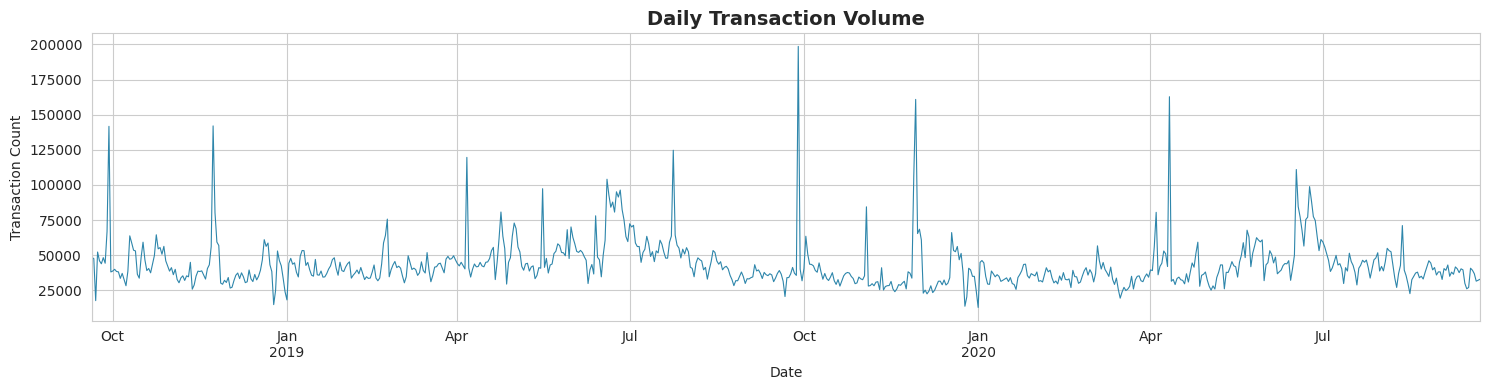

日均交易量: 43308, 峰值: 198,622
周末 vs 工作日均值: 43253 vs 43331


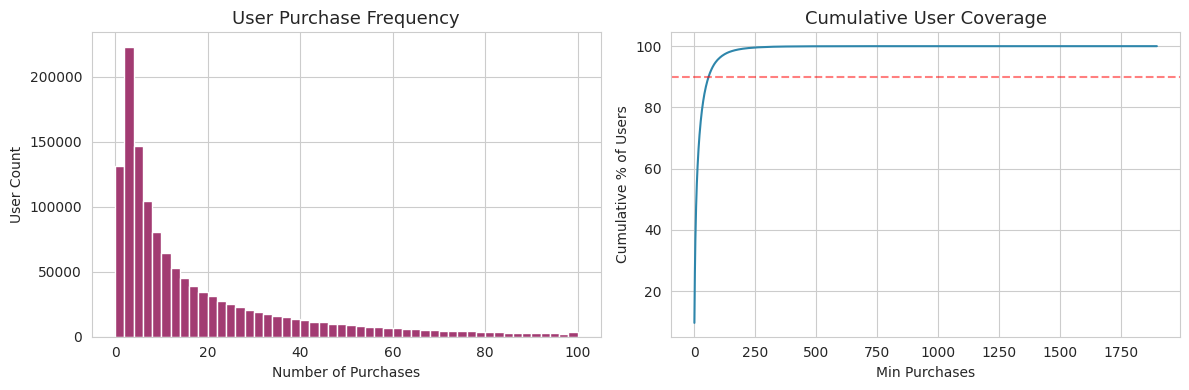

用户中位数购买次数: 9, 均值: 23.3


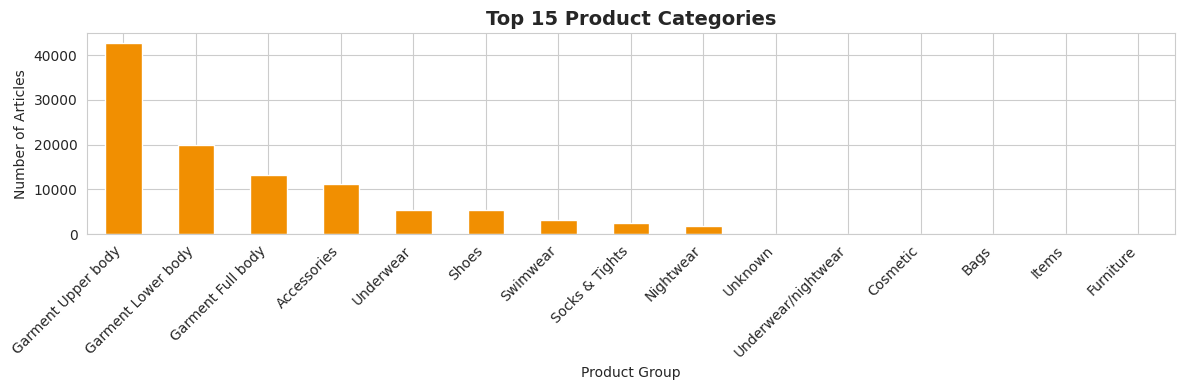


短期复购效应分析（50,000 用户采样）：
  21天内有复购行为的用户比例: 49.1%


0

In [3]:
# ============================================
# Cell 3: 探索性数据分析（EDA）
# ============================================
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# 3.1 日交易量时序
daily_volume = transactions.groupby('t_dat').size()
plt.figure(figsize=(15, 4))
daily_volume.plot(color='#2E86AB', linewidth=0.8)
plt.title('Daily Transaction Volume', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.show()
print(f'日均交易量: {daily_volume.mean():.0f}, 峰值: {daily_volume.max():,}')
print(f'周末 vs 工作日均值: {daily_volume[daily_volume.index.dayofweek >= 5].mean():.0f} vs {daily_volume[daily_volume.index.dayofweek < 5].mean():.0f}')
del daily_volume; gc.collect()

# 3.2 用户购买频次分布
user_freq = transactions.groupby('customer_id').size()
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
user_freq.hist(bins=50, range=(0, 100), color='#A23B72', edgecolor='white')
plt.title('User Purchase Frequency', fontsize=13)
plt.xlabel('Number of Purchases')
plt.ylabel('User Count')
plt.subplot(1, 2, 2)
user_freq.value_counts().sort_index().cumsum().div(len(user_freq)).mul(100).plot(color='#2E86AB')
plt.title('Cumulative User Coverage', fontsize=13)
plt.xlabel('Min Purchases')
plt.ylabel('Cumulative % of Users')
plt.axhline(90, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print(f'用户中位数购买次数: {user_freq.median():.0f}, 均值: {user_freq.mean():.1f}')

# 3.3 商品品类分布
top_categories = articles['product_group_name'].value_counts().head(15)
plt.figure(figsize=(12, 4))
top_categories.plot(kind='bar', color='#F18F01')
plt.title('Top 15 Product Categories', fontsize=14, fontweight='bold')
plt.xlabel('Product Group')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
del user_freq, top_categories; gc.collect()

# 3.4 短期复购效应分析（报告核心发现）
sample_users = transactions['customer_id'].drop_duplicates().sample(n=50000, random_state=SEED)
sample_trans = transactions[transactions['customer_id'].isin(sample_users)].copy()
repurchase_21d = sample_trans.sort_values('t_dat').groupby('customer_id')['article_id'].apply(
    lambda x: (x.duplicated(keep=False)).sum() > 0
)
print(f'\n短期复购效应分析（50,000 用户采样）：')
print(f'  21天内有复购行为的用户比例: {repurchase_21d.mean()*100:.1f}%')
del sample_users, sample_trans, repurchase_21d; gc.collect()

In [4]:
# ============================================
# Cell 4: 时间划分与数据过滤
# ============================================
# 训练：2020-09-16 之前；验证：2020-09-16 ~ 2020-09-22
train_weeks = transactions[transactions['t_dat'] < '2020-09-16'].copy()
val_weeks = transactions[
    (transactions['t_dat'] >= '2020-09-16') & 
    (transactions['t_dat'] < '2020-09-23')
].copy()
print(f'训练集: {train_weeks.shape}, 验证集: {val_weeks.shape}')

# 严格过滤：用户 >= 3 次购买，商品 >= 10 次被购买
user_counts = train_weeks.groupby('customer_id').size()
keep_users = user_counts[user_counts >= 3].index
item_counts = train_weeks['article_id'].value_counts()
keep_items = item_counts[item_counts >= 10].index

train_weeks = train_weeks[
    train_weeks['customer_id'].isin(keep_users) &
    train_weeks['article_id'].isin(keep_items)
]
print(f'过滤后训练集: {train_weeks.shape}')
print(f'保留用户: {len(keep_users):,}, 保留商品: {len(keep_items):,}')
del user_counts, item_counts; gc.collect()

训练集: (31548013, 5), 验证集: (240311, 5)
过滤后训练集: (31078555, 5)
保留用户: 1,099,105, 保留商品: 82,759


23

In [5]:
# ============================================
# Cell 5: 候选商品召回 — 复购召回
# 策略：10^9 * (1/(day_rank+1)) + purchase_count
# ============================================
def repurchase_candidates(trans_df, day_weight=1e9):
    stats = trans_df.groupby(['customer_id', 'article_id']).agg(
        last_date=('t_dat', 'max'),
        purchase_count=('article_id', 'count')
    ).reset_index()
    max_date = trans_df['t_dat'].max()
    stats['day_rank'] = (max_date - stats['last_date']).dt.days
    stats['score'] = day_weight * 1.0 / (stats['day_rank'] + 1) + stats['purchase_count']
    stats = stats.sort_values(['customer_id', 'score'], ascending=[True, False])
    return stats.groupby('customer_id').head(12)[['customer_id', 'article_id']]

candidates_rep = repurchase_candidates(train_weeks)
print(f'复购召回候选: {candidates_rep.shape}')
print(f'覆盖用户: {candidates_rep["customer_id"].nunique():,}')

复购召回候选: (9869141, 2)
覆盖用户: 1,099,088


In [6]:
# ============================================
# Cell 6: 候选商品召回 — Item2Item 共现召回
# 基于商品共现矩阵的相似商品推荐
# ============================================
def build_item2item_sparse(trans_df, top_k=3, min_cooc=5):
    user_enc = LabelEncoder()
    item_enc = LabelEncoder()
    rows = user_enc.fit_transform(trans_df['customer_id'])
    cols = item_enc.fit_transform(trans_df['article_id'])
    data = np.ones(len(trans_df), dtype=np.int8)

    user_item = csr_matrix((data, (rows, cols)),
                           shape=(len(user_enc.classes_), len(item_enc.classes_)))
    cooc = user_item.T.dot(user_item)  # 物品 × 物品共现矩阵
    cooc.setdiag(0)
    cooc.eliminate_zeros()
    cooc.data[cooc.data < min_cooc] = 0
    cooc.eliminate_zeros()

    cooc = cooc.tolil()
    item_sim = {}
    for i in range(cooc.shape[0]):
        row = cooc.getrowview(i)
        if row.nnz == 0:
            continue
        ranked = row.toarray().ravel().argsort()[::-1][:top_k]
        if len(ranked) == 0:
            continue
        orig_item = item_enc.inverse_transform([i])[0]
        sim_items = item_enc.inverse_transform(ranked)
        item_sim[orig_item] = list(zip(sim_items, [0] * len(sim_items)))
    return item_sim

item_sim = build_item2item_sparse(train_weeks, top_k=3, min_cooc=5)

def item2item_candidates(trans_df, item_sim, top_k=3):
    recent = trans_df.sort_values('t_dat').groupby('customer_id')['article_id'].apply(
        lambda x: list(x.unique())[-5:]
    ).to_dict()
    candidates = []
    for cust, items in recent.items():
        sim_set = set()
        for it in items:
            if it in item_sim:
                for sim_it, _ in item_sim[it][:top_k]:
                    sim_set.add(sim_it)
        for s in sim_set:
            candidates.append((cust, s))
    return pd.DataFrame(candidates, columns=['customer_id', 'article_id']).drop_duplicates()

candidates_i2i = item2item_candidates(train_weeks, item_sim)
print(f'Item2Item 召回候选: {candidates_i2i.shape}')
del item_sim; gc.collect()

Item2Item 召回候选: (14345238, 2)


0

In [7]:
# ============================================
# Cell 7: 候选商品召回 — Popular + Category Popular
# ============================================
# 7.1 Global Popular：选取购买最多的前 30 个（原 60，减半以控制内存）
popular_items = train_weeks['article_id'].value_counts().head(30).index
all_users = train_weeks['customer_id'].unique()
# 不创建全量笛卡尔积，直接采样 10% 用户 × 30 商品
sample_size = max(1, int(len(all_users) * 0.1))
sampled_users = np.random.choice(all_users, size=sample_size, replace=False)
candidates_pop = pd.DataFrame({
    'customer_id': np.repeat(sampled_users, len(popular_items)),
    'article_id': np.tile(popular_items.values, len(sampled_users))
})
print(f'Global Popular 候选: {candidates_pop.shape}')
del all_users, sampled_users; gc.collect()

# 7.2 Category Popular：用户偏好品类 × 品类热门商品
article_cat = articles[['article_id', 'index_group_name']].copy()
# 用户-品类偏好
user_cat = train_weeks.merge(article_cat, on='article_id')
user_cat_count = user_cat.groupby(['customer_id', 'index_group_name']).size().reset_index(name='cat_count')
top_user_cats = user_cat_count.sort_values(['customer_id', 'cat_count'], ascending=[True, False])
top_user_cats = top_user_cats.groupby('customer_id').head(3)
# 品类-热门商品
cat_item_pop = user_cat.groupby(['index_group_name', 'article_id']).size().reset_index(name='pop')
cat_item_pop = cat_item_pop.sort_values(['index_group_name', 'pop'], ascending=[True, False])
top_cat_items = cat_item_pop.groupby('index_group_name').head(20)
# 合并生成候选
candidates_catpop = top_user_cats.merge(top_cat_items, on='index_group_name')
candidates_catpop = candidates_catpop[['customer_id', 'article_id']].drop_duplicates()
# 剔除复购中已出现的
rep_dup = candidates_rep.copy()
rep_dup['_dup'] = 1
candidates_catpop = candidates_catpop.merge(rep_dup, on=['customer_id', 'article_id'], how='left')
candidates_catpop = candidates_catpop[candidates_catpop['_dup'].isna()].drop('_dup', axis=1)
print(f'Category Popular 候选: {candidates_catpop.shape}')
del user_cat, user_cat_count, top_user_cats, cat_item_pop, top_cat_items, article_cat, rep_dup; gc.collect()

Global Popular 候选: (3297240, 2)
Category Popular 候选: (48617418, 2)


0

In [8]:
# ============================================
# Cell 8: 合并候选集，每用户最多 20 个
# ============================================
all_candidates = pd.concat([
    candidates_rep,
    candidates_i2i,
    candidates_pop,
    candidates_catpop
]).drop_duplicates()
all_candidates = all_candidates.groupby('customer_id').head(20)
print(f'合并候选集: {all_candidates.shape}')
print(f'覆盖用户: {all_candidates["customer_id"].nunique():,}')
print(f'平均候选数/用户: {all_candidates.groupby("customer_id").size().mean():.1f}')
del candidates_rep, candidates_i2i, candidates_pop, candidates_catpop; gc.collect()

合并候选集: (21981760, 2)
覆盖用户: 1,099,088
平均候选数/用户: 20.0


23

In [9]:
# ============================================
# Cell 9: PyTorch GPU 截断 SVD 矩阵分解
# 在 P100 GPU 上训练 64 维 user/item 隐向量
# 替代原方案中 CPU-only 的 LightFM
# ============================================
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import coo_matrix

print('正在训练 PyTorch GPU 矩阵分解 (factors=64)...')

# 编码用户和商品
user_enc = LabelEncoder()
item_enc = LabelEncoder()
user_enc.fit(train_weeks['customer_id'])
item_enc.fit(train_weeks['article_id'])

rows = user_enc.transform(train_weeks['customer_id'])
cols = item_enc.transform(train_weeks['article_id'])
data = np.ones(len(train_weeks), dtype=np.float32)

n_users = len(user_enc.classes_)
n_items = len(item_enc.classes_)

# 构建稀疏 COO 矩阵并迁移到 GPU
matrix_coo = coo_matrix((data, (rows, cols)), shape=(n_users, n_items))
indices = torch.LongTensor([matrix_coo.row, matrix_coo.col])
values = torch.FloatTensor(matrix_coo.data)
size = torch.Size(matrix_coo.shape)
matrix_torch = torch.sparse_coo_tensor(indices, values, size).to(device)

print(f'稀疏矩阵形状: ({n_users:,}, {n_items:,}), 非零元: {matrix_coo.nnz:,}')
print(f'GPU 显存占用: {torch.cuda.memory_allocated() / 1024**2:.0f} MB')

# ===== GPU 截断 SVD =====
factors = 64
# matrix_torch 是 (users, items), 对其转置做 SVD
# matrix_torch.t() ~ U @ diag(S) @ V.t()
# U: (items, k), 列向量是物品空间的奇异方向
U, S, V = torch.svd_lowrank(matrix_torch.t(), q=factors + 10)

# 物品嵌入 = U 的前 factors 列 (保留在 GPU 上计算 user_emb)
item_emb_tensor = U[:, :factors]                          # (n_items, factors)
# 用户嵌入 = 交互矩阵 × 物品嵌入 (将用户投射到物品语义空间)
user_emb_tensor = torch.sparse.mm(matrix_torch, item_emb_tensor)  # (n_users, factors)

# 迁回 CPU
user_emb = user_emb_tensor.cpu().numpy()
item_emb = item_emb_tensor.cpu().numpy()
print(f'嵌入维度: user={user_emb.shape}, item={item_emb.shape}')

# 构建映射字典：原始 ID → 嵌入索引
user_map = {uid: i for i, uid in enumerate(user_enc.classes_)}
item_map = {iid: i for i, iid in enumerate(item_enc.classes_)}

# 保存到 CPU 内存供测试集复用
user_emb_cpu = user_emb.copy()
item_emb_cpu = item_emb.copy()

# 释放 GPU 资源
del matrix_torch, U, S, V, user_emb_tensor, item_emb_tensor, indices, values, matrix_coo
torch.cuda.empty_cache()
gc.collect()
print(f'GPU 显存已释放: {torch.cuda.memory_allocated() / 1024**2:.0f} MB')

# 为候选集添加嵌入特征
def add_embedding_features(candidates_df, user_emb, item_emb, user_map, item_map):
    cand = candidates_df.copy()
    cand['_uidx'] = cand['customer_id'].map(user_map)
    cand['_iidx'] = cand['article_id'].map(item_map)
    before = len(cand)
    cand = cand[cand['_uidx'].notna() & cand['_iidx'].notna()]
    if len(cand) < before:
        print(f'丢弃 {before - len(cand)} 个冷启动候选')
    u_idx = cand['_uidx'].astype(int).values
    i_idx = cand['_iidx'].astype(int).values
    u_emb = user_emb[u_idx]
    i_emb = item_emb[i_idx]
    cand['lfm_dot'] = np.sum(u_emb * i_emb, axis=1)
    cand['lfm_cosine'] = np.sum(u_emb * i_emb, axis=1) / (
        np.linalg.norm(u_emb, axis=1) * np.linalg.norm(i_emb, axis=1) + 1e-10
    )
    for j in range(8):
        cand[f'lfm_u_{j}'] = u_emb[:, j]
        cand[f'lfm_i_{j}'] = i_emb[:, j]
    cand.drop(['_uidx', '_iidx'], axis=1, inplace=True)
    return cand

all_candidates = add_embedding_features(all_candidates, user_emb_cpu, item_emb_cpu, user_map, item_map)
print(f'嵌入特征添加完成，候选集: {all_candidates.shape}')

正在训练 PyTorch GPU 矩阵分解 (factors=64)...
稀疏矩阵形状: (1,099,088, 82,759), 非零元: 31,078,555
GPU 显存占用: 593 MB
嵌入维度: user=(1099088, 64), item=(82759, 64)
GPU 显存已释放: 0 MB
嵌入特征添加完成，候选集: (21981760, 20)


In [10]:
# ============================================
# 10.1 商品属性处理 (保持 LabelEncoder 节省空间)
# ============================================
print("Step 10.1: Article encoding...")
article_cat_cols = [
    'product_group_name', 'colour_group_name', 'department_name',
    'index_group_name', 'section_name', 'garment_group_name'
]

# 这里的 LabelEncoder 仅用于最终模型，我们还需要 OHE 来做用户画像
article_ohe = pd.get_dummies(articles[article_cat_cols], dtype='float32') # 显式用 float32
article_ohe['article_id'] = articles['article_id'].values

# ============================================
# 10.2 用户 × 商品属性聚合 (矩阵乘法优化版)
# ============================================
print("Step 10.2: Calculating User-Attribute features using Sparse Matrix...")

# 1. 为 customer 和 article 建立连续索引（稀疏矩阵要求）
unique_customers = train_weeks['customer_id'].unique()
unique_articles = articles['article_id'].unique()

cust_map = {id: i for i, id in enumerate(unique_customers)}
art_map = {id: i for i, id in enumerate(unique_articles)}

# 2. 构造 购买关系 稀疏矩阵 (User-Item Matrix)
# 行: 客户, 列: 商品, 值: 购买次数
row = train_weeks['customer_id'].map(cust_map).values
col = train_weeks['article_id'].map(art_map).values
data = np.ones(len(train_weeks), dtype='float32')

# 形状: (总用户数, 总商品数)
user_item_sparse = csr_matrix((data, (row, col)), 
                              shape=(len(unique_customers), len(unique_articles)))

# 3. 构造 商品属性 矩阵 (Item-Attribute Matrix)
# 先对齐 article_ohe 的顺序与 art_map 一致
article_ohe_sorted = pd.DataFrame({'article_id': unique_articles}).merge(article_ohe, on='article_id', how='left').drop(columns='article_id')
attr_matrix = article_ohe_sorted.values.astype('float32')

# 4. 矩阵相乘: (User-Item) @ (Item-Attr) = (User-Attr)
# 这一步极其快速且节省内存
user_attr_dense = user_item_sparse.dot(attr_matrix)

# 5. 归一化 (除以总购买次数) 得到偏好比例
user_counts = np.array(user_item_sparse.sum(axis=1)).flatten()
user_counts[user_counts == 0] = 1 # 防止除以0
user_attr_dense = user_attr_dense / user_counts[:, None]

# 6. 转回 Pandas DataFrame
attr_cols = [f'user_attr_{c}' for c in article_ohe_sorted.columns]
user_attr_feat = pd.DataFrame(user_attr_dense, columns=attr_cols)
user_attr_feat['customer_id'] = unique_customers

# ===== 关键内存优化：将 402 列用户属性转为 float16 =====
# 这些值范围在 [0, 1] 之间，float16 精度完全足够
user_attr_cols_list = [c for c in user_attr_feat.columns if c.startswith('user_attr_')]
user_attr_feat[user_attr_cols_list] = user_attr_feat[user_attr_cols_list].astype('float16')

print(f'用户×属性特征计算完成: {user_attr_feat.shape}')
print(f'  memory: {user_attr_feat.memory_usage(deep=True).sum() / 1024**2:.1f} MB (float16)')

# 清理
del user_item_sparse, attr_matrix, user_attr_dense, article_ohe, article_ohe_sorted
gc.collect()

# 10.3 用户静态特征
customer_static = customers[['customer_id', 'age']].copy()
customer_static['age'] = customer_static['age'].fillna(customer_static['age'].median())
customer_static['age_bin'] = pd.cut(
    customer_static['age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=False
).fillna(0).astype(int)
print(f'用户静态特征: {customer_static.shape}')

Step 10.1: Article encoding...
Step 10.2: Calculating User-Attribute features using Sparse Matrix...
用户×属性特征计算完成: (1099088, 402)
  memory: 967.5 MB (float16)
用户静态特征: (1371980, 3)


In [11]:
TRAIN_END = pd.Timestamp('2020-09-16')

# ============================================
# 11.0 释放内存：保存 all_candidates 到磁盘
# ============================================
print("Saving all_candidates to disk to free memory...")
all_candidates.to_pickle('all_candidates.pkl')
del all_candidates
gc.collect()

# ============================================
# 11.1 轻量化交易数据并释放原始表
# ============================================
print("Lightening transactions DataFrame...")
trans_light = transactions[['customer_id', 'article_id', 't_dat', 'price', 'sales_channel_id']].copy()
# Kaggle H&M 的 customer_id 是 object 类型，不转换；数值列压到最小
if trans_light['article_id'].dtype == 'int64':
    trans_light['article_id'] = trans_light['article_id'].astype('int32')
if trans_light['price'].dtype == 'float64':
    trans_light['price'] = trans_light['price'].astype('float32')
if trans_light['sales_channel_id'].dtype in ('int64', 'int32'):
    trans_light['sales_channel_id'] = trans_light['sales_channel_id'].astype('int8')

# 释放原始交易表
del transactions
gc.collect()
print(f"trans_light: {trans_light.shape}, "
      f"mem: {trans_light.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# ============================================
# 11.2 提前按日期过滤（供所有特征函数复用）
# ============================================
trans_f = trans_light[trans_light['t_dat'] < TRAIN_END].copy()
del trans_light
gc.collect()
print(f"Filtered trans_f: {trans_f.shape}")

# ============================================
# 11.3 用户动态特征（无实质变化，仅使用 trans_f）
# ============================================
def user_dynamic_features(temp, end_date):
    print("Computing User Dynamic Features...")
    f = temp.groupby('customer_id').agg(
        user_avg_price=('price', 'mean'),
        user_std_price=('price', 'std'),
        user_avg_sales_channel=('sales_channel_id', 'mean'),
        user_purchase_count=('article_id', 'count'),
        user_unique_items=('article_id', 'nunique'),
        user_last_purchase=('t_dat', 'max'),
        user_first_purchase=('t_dat', 'min')
    ).reset_index()

    f['user_avg_price'] = f['user_avg_price'].astype('float32')
    f['user_std_price'] = f['user_std_price'].astype('float32')
    f['user_avg_sales_channel'] = f['user_avg_sales_channel'].astype('float32')
    f['user_purchase_count'] = f['user_purchase_count'].astype('int32')
    f['user_unique_items'] = f['user_unique_items'].astype('int32')
    f['user_active_days'] = (end_date - f['user_last_purchase']).dt.days.astype('int16')
    f['user_lifetime_days'] = (f['user_last_purchase'] - f['user_first_purchase']).dt.days.astype('int16')
    f.drop(['user_last_purchase', 'user_first_purchase'], axis=1, inplace=True)
    f.fillna(0, inplace=True)
    return f

user_dyn = user_dynamic_features(trans_f, TRAIN_END)
gc.collect()
print(f"user_dyn: {user_dyn.shape}")

# ============================================
# 11.4 商品动态特征
# ============================================
def item_dynamic_features(temp, end_date):
    print("Computing Item Dynamic Features...")
    f = temp.groupby('article_id').agg(
        item_avg_price=('price', 'mean'),
        item_std_price=('price', 'std'),
        item_avg_sales_channel=('sales_channel_id', 'mean'),
        item_purchase_count=('article_id', 'count'),
        item_unique_users=('customer_id', 'nunique'),
        item_last_purchase=('t_dat', 'max'),
        item_first_purchase=('t_dat', 'min')
    ).reset_index()

    for c in ['item_avg_price', 'item_std_price', 'item_avg_sales_channel']:
        f[c] = f[c].astype('float32')
    f['item_purchase_count'] = f['item_purchase_count'].astype('int32')
    f['item_unique_users'] = f['item_unique_users'].astype('int32')
    f['item_recency'] = (end_date - f['item_last_purchase']).dt.days.astype('int16')
    f['item_lifetime_days'] = (f['item_last_purchase'] - f['item_first_purchase']).dt.days.astype('int16')
    f.drop(['item_last_purchase', 'item_first_purchase'], axis=1, inplace=True)
    f.fillna(0, inplace=True)
    return f

item_dyn = item_dynamic_features(trans_f, TRAIN_END)
gc.collect()
print(f"item_dyn: {item_dyn.shape}")

# ============================================
# 11.5 User-Item 交互对特征（分块计算，避免 OOM）
# 核心思路：将用户按哈希分块，每块仅对该块内用户做 groupby
# ============================================
def pair_features_chunked(temp, end_date, n_chunks=20):
    """分块计算 pair 特征，每块独立 groupby，避免大哈希表一次建完"""
    print(f"Computing Pair Features in {n_chunks} chunks...")

    # 为 customer_id 分配块号（factorize 得到整数码再取模）
    cust_codes, _ = pd.factorize(temp['customer_id'])
    chunk_ids = cust_codes % n_chunks
    temp = temp.copy()
    temp['_chunk'] = chunk_ids

    all_parts = []
    for i in range(n_chunks):
        part = temp.loc[temp['_chunk'] == i, ['customer_id', 'article_id', 't_dat', 'price']]
        if len(part) == 0:
            continue

        pair = part.groupby(['customer_id', 'article_id'], as_index=False).agg(
            pair_purchase_count=('price', 'count'),
            pair_last_date=('t_dat', 'max'),
            pair_first_date=('t_dat', 'min'),
            pair_avg_price=('price', 'mean')
        )
        pair['pair_purchase_count'] = pair['pair_purchase_count'].astype('int16')
        pair['pair_avg_price'] = pair['pair_avg_price'].astype('float32')
        pair['pair_recency'] = (end_date - pair['pair_last_date']).dt.days.astype('int16')
        pair['pair_lifetime'] = (pair['pair_last_date'] - pair['pair_first_date']).dt.days.astype('int16')
        pair.drop(['pair_last_date', 'pair_first_date'], axis=1, inplace=True)
        all_parts.append(pair)

        # 每块结束后立即释放
        del part, pair
        gc.collect()

        if (i + 1) % 5 == 0 or i == n_chunks - 1:
            print(f"  Pair chunk {i+1}/{n_chunks} done")

    result = pd.concat(all_parts, ignore_index=True)
    # 最终确保 dtype
    result['pair_purchase_count'] = result['pair_purchase_count'].astype('int16')
    result['pair_recency'] = result['pair_recency'].astype('int16')
    result['pair_lifetime'] = result['pair_lifetime'].astype('int16')
    result['pair_avg_price'] = result['pair_avg_price'].astype('float32')
    print(f"Pair features done: {result.shape}")
    return result

pair_feat = pair_features_chunked(trans_f, TRAIN_END, n_chunks=20)
print(f'User-Item 对特征计算完成: {pair_feat.shape}')

# 释放 trans_f — 不再需要原始交易明细
del trans_f
gc.collect()

Saving all_candidates to disk to free memory...
Lightening transactions DataFrame...
trans_light: (31788324, 5), mem: 4183.6 MB
Filtered trans_f: (31548013, 5)
Computing User Dynamic Features...
user_dyn: (1356709, 8)
Computing Item Dynamic Features...
item_dyn: (103880, 8)
Computing Pair Features in 20 chunks...
  Pair chunk 5/20 done
  Pair chunk 10/20 done
  Pair chunk 15/20 done
  Pair chunk 20/20 done
Pair features done: (27101148, 6)
User-Item 对特征计算完成: (27101148, 6)


0

In [12]:
# ============================================
# 12.0 变量自检与修复逻辑
# ============================================
print("检查必要变量...")

# 修复 article_cat_encoded 丢失问题
if 'article_cat_encoded' not in locals():
    print("-> 发现 article_cat_encoded 丢失，正在重新生成...")
    article_cat_cols = ['product_group_name', 'colour_group_name', 'department_name',
                        'index_group_name', 'section_name', 'garment_group_name']
    article_cat_encoded = articles[['article_id'] + article_cat_cols].copy()
    for col in article_cat_cols:
        article_cat_encoded[col] = LabelEncoder().fit_transform(article_cat_encoded[col].astype(str)).astype('int8')
    gc.collect()

# 校验其他关键表是否存在
required_vars = ['customer_static', 'user_dyn', 'item_dyn', 'pair_feat', 'user_attr_feat']
for v in required_vars:
    if v not in locals():
        raise NameError(f"严重错误：变量 {v} 不存在。请确保你运行了 Cell 10 和 Cell 11。")

# ============================================
# 12.1 极致压缩函数
# ============================================
def reduce_mem_usage(df, skip_cols=None):
    """压缩数据类型。skip_cols 中的列跳过（用于保护 float16 列不被升级为 float32）"""
    for col in df.columns:
        if skip_cols and col in skip_cols:
            continue
        col_type = df[col].dtype
        if col_type not in ['object', 'category'] and not str(col_type).startswith('datetime'):
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type).startswith('int'):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            elif str(col_type).startswith('float'):
                if col_type == np.float16:
                    continue
                df[col] = df[col].astype(np.float32)
    return df

# 加载保存在磁盘上的 all_candidates
print("Loading all_candidates from disk...")
all_candidates = pd.read_pickle('all_candidates.pkl')
gc.collect()

# 预压缩小表
print("预压缩特征表以腾出空间...")
customer_static = reduce_mem_usage(customer_static)
user_dyn = reduce_mem_usage(user_dyn)
item_dyn = reduce_mem_usage(item_dyn)
pair_feat = reduce_mem_usage(pair_feat)
user_attr_feat = reduce_mem_usage(user_attr_feat)
article_cat_encoded = reduce_mem_usage(article_cat_encoded)
gc.collect()

# ============================================
# 12.2 分区对齐合并
# ============================================
def add_partition(df, n_parts):
    cust_codes, _ = pd.factorize(df['customer_id'])
    df['_part'] = cust_codes % n_parts
    return df

N_PARTS = 20
add_partition(pair_feat, N_PARTS)
add_partition(all_candidates, N_PARTS)

def merge_partition_core(cand_df, user_dyn_df, item_dyn_df,
                          customer_static_df, article_cat_encoded_df,
                          part_id):
    mask = cand_df['_part'] == part_id
    cand_part = cand_df.loc[mask].drop('_part', axis=1)
    print(f"  分区 {part_id+1}/{N_PARTS}: candidate={len(cand_part):,}")
    chunk = cand_part.copy()
    chunk = chunk.merge(customer_static_df, on='customer_id', how='left')
    chunk = chunk.merge(user_dyn_df, on='customer_id', how='left')
    chunk = chunk.merge(item_dyn_df, on='article_id', how='left')
    chunk = chunk.merge(pair_feat.loc[pair_feat['_part'] == part_id].drop('_part', axis=1),
                        on=['customer_id', 'article_id'], how='left')
    for c in ['pair_purchase_count', 'pair_recency', 'pair_lifetime']:
        if c in chunk.columns:
            chunk[c] = chunk[c].fillna(0).astype('int16')
    if 'pair_avg_price' in chunk.columns:
        chunk['pair_avg_price'] = chunk['pair_avg_price'].fillna(0).astype('float32')
    chunk = chunk.merge(article_cat_encoded_df, on='article_id', how='left')
    chunk = reduce_mem_usage(chunk)
    gc.collect()
    return chunk

# ============================================
# 12.3 分区合并
# ============================================
if 'all_candidates' in locals():
    print("\n阶段 1/3: 分区合并（保存到磁盘）...")
    for pid in range(N_PARTS):
        part_df = merge_partition_core(
            all_candidates, user_dyn, item_dyn,
            customer_static, article_cat_encoded, pid
        )
        part_df.to_pickle(f'full_data_part_{pid}.pkl')
        size_mb = part_df.memory_usage(deep=True).sum() / 1024**2
        print(f"    -> 已保存 part_{pid}.pkl ({size_mb:.0f} MB)")
        del part_df; gc.collect()

    del all_candidates, pair_feat, user_dyn, item_dyn, customer_static, article_cat_encoded
    gc.collect()

    # ============================================
    # 12.4 阶段 2: 加载并拼接
    # ============================================
    print("\n阶段 2/3: 加载并拼接分区...")
    full_data = None
    for pid in range(N_PARTS):
        part_df = pd.read_pickle(f'full_data_part_{pid}.pkl')
        if full_data is None:
            full_data = part_df
        else:
            full_data = pd.concat([full_data, part_df], ignore_index=True)
        del part_df; gc.collect()
        import os as _os
        _os.remove(f'full_data_part_{pid}.pkl')

    print(f"  拼接完成: {len(full_data):,} 行, {len(full_data.columns)} 列")
    print(f"  memory: {full_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB (不含 user_attr)")

    # ============================================
    # 12.5 阶段 3: GPU PCA 降维 402→32 + 合并
    # ============================================
    print("\n阶段 3/3: GPU PCA 降维 402→32 + 合并...")

    attr_wide_cols = [c for c in user_attr_feat.columns if c.startswith('user_attr_')]
    attr_values = user_attr_feat[attr_wide_cols].values.astype('float32')
    n_users, n_attrs = attr_values.shape
    print(f"  用户属性矩阵: {n_users:,} × {n_attrs} = {n_users * n_attrs * 4 / 1024**3:.1f} GB (float32 on GPU)")

    import torch
    attr_tensor = torch.tensor(attr_values, dtype=torch.float32).to(device)
    attr_mean = attr_tensor.mean(dim=0, keepdim=True)
    attr_centered = attr_tensor - attr_mean
    _U, _S, _V = torch.svd_lowrank(attr_centered, q=36)

    n_components = 32
    pca_comps = _V[:, :n_components].contiguous()
    reduced = torch.mm(attr_centered, pca_comps).cpu().numpy()

    # 保存 PCA 参数为全局供测试集复用（必须在 del reduced 之前）
    user_attr_mean = attr_mean.cpu().numpy().ravel()
    user_attr_pca_vec = pca_comps.cpu().numpy()

    # 释放 GPU（注意：reduced 已经从 GPU 拷回 CPU，可以安全删除 GPU tensor）
    del attr_tensor, attr_centered, _U, _S, _V, pca_comps
    torch.cuda.empty_cache()

    # 构建 32 维 PCA 特征表（使用 CPU 上的 reduced）
    pca_cols = [f'user_attr_pca_{i:02d}' for i in range(n_components)]
    user_attr_pca = pd.DataFrame(reduced, columns=pca_cols, dtype='float32')
    user_attr_pca['customer_id'] = user_attr_feat['customer_id'].values

    # 现在可以安全释放 reduced 和原始 402 列
    del reduced, user_attr_feat, attr_values
    gc.collect()

    print(f"  PCA 降维完成: {user_attr_pca.shape} ({n_attrs} → {n_components})")
    print(f"  GPU 显存: {torch.cuda.memory_allocated() / 1024**2:.0f} MB")

    # 合并 32 维 PCA 特征
    before_mem = full_data.memory_usage(deep=True).sum() / 1024**2
    full_data = full_data.merge(user_attr_pca, on='customer_id', how='left')
    pca_feat_cols = [c for c in full_data.columns if c.startswith('user_attr_pca_')]
    if pca_feat_cols:
        full_data[pca_feat_cols] = full_data[pca_feat_cols].fillna(0).astype('float32')
    gc.collect()

    after_mem = full_data.memory_usage(deep=True).sum() / 1024**2
    print(f'成功! 最终特征表: {full_data.shape}')
    print(f'  memory: {after_mem:.1f} MB (含 user_attr_pca float32)')

    del user_attr_pca
    gc.collect()
else:
    print("错误：all_candidates 不在内存中，请重新运行候选集生成部分。")

检查必要变量...
-> 发现 article_cat_encoded 丢失，正在重新生成...
Loading all_candidates from disk...
预压缩特征表以腾出空间...

阶段 1/3: 分区合并（保存到磁盘）...
  分区 1/20: candidate=1,099,100
    -> 已保存 part_0.pkl (281 MB)
  分区 2/20: candidate=1,099,100
    -> 已保存 part_1.pkl (281 MB)
  分区 3/20: candidate=1,099,100
    -> 已保存 part_2.pkl (281 MB)
  分区 4/20: candidate=1,099,100
    -> 已保存 part_3.pkl (281 MB)
  分区 5/20: candidate=1,099,100
    -> 已保存 part_4.pkl (281 MB)
  分区 6/20: candidate=1,099,100
    -> 已保存 part_5.pkl (281 MB)
  分区 7/20: candidate=1,099,100
    -> 已保存 part_6.pkl (281 MB)
  分区 8/20: candidate=1,099,100
    -> 已保存 part_7.pkl (281 MB)
  分区 9/20: candidate=1,099,080
    -> 已保存 part_8.pkl (281 MB)
  分区 10/20: candidate=1,099,080
    -> 已保存 part_9.pkl (281 MB)
  分区 11/20: candidate=1,099,080
    -> 已保存 part_10.pkl (281 MB)
  分区 12/20: candidate=1,099,080
    -> 已保存 part_11.pkl (281 MB)
  分区 13/20: candidate=1,099,080
    -> 已保存 part_12.pkl (281 MB)
  分区 14/20: candidate=1,099,080
    -> 已保存 part_13.pkl (281 MB)

In [13]:
# ============================================
# Cell 13: 标签构造（验证集购买记录作为正样本）
# ============================================
val_pos = val_weeks[['customer_id', 'article_id']].drop_duplicates()
val_pos['label'] = 1

train_data = full_data.merge(val_pos, on=['customer_id', 'article_id'], how='left')
train_data['label'] = train_data['label'].fillna(0).astype(int)

print(f'训练数据: {train_data.shape}')
print(f'标签分布:\n{train_data["label"].value_counts().to_string()}')
print(f'正样本率: {train_data["label"].mean()*100:.4f}%')
del full_data, val_pos; gc.collect()

训练数据: (21981760, 79)
标签分布:
0    21974190
1        7570
正样本率: 0.0344%


23

In [14]:
# ============================================
# Cell 14: LightGBM 排序模型（GPU 训练）
# ============================================
# 降采样负样本到 1:10，减小训练集大小避免训练时 OOM
print("负样本降采样 (保留全部正样本, 负样本 10x)...")
pos = train_data['label'] == 1
neg = train_data['label'] == 0
n_pos = pos.sum()
n_neg = neg.sum()
print(f"  降采样前: {len(train_data):,} 行 (正={n_pos:,}, 负={n_neg:,}, 比例=1:{n_neg//max(n_pos,1)})")

target_neg = min(n_neg, n_pos * 10)
neg_idx = train_data.index[neg]
keep_neg = np.random.choice(neg_idx, size=target_neg, replace=False)
keep_idx = np.concatenate([train_data.index[pos], keep_neg])
train_data = train_data.loc[keep_idx].reset_index(drop=True)
gc.collect()
print(f"  降采样后: {len(train_data):,} 行 (正={n_pos:,}, 负={target_neg:,})")

# ===== 准备训练数据 =====
features = [c for c in train_data.columns 
            if c not in ['customer_id', 'article_id', 'label',
                         'last_date', 'last_purchase', 'first_purchase',
                         'pair_last_date', 'pair_first_date', 't_dat',
                         'user_last_purchase', 'user_first_purchase',
                         'item_last_purchase', 'item_first_purchase']]

X = train_data[features]
y = train_data['label'].astype(int)

cat_cols = [c for c in X.columns if X[c].dtype.name in ['object', 'category']]
for c in cat_cols:
    X[c] = X[c].astype('category')

groups = train_data['customer_id']

# 释放 train_data — 不再需要
del train_data
gc.collect()

gkf = GroupKFold(n_splits=3)
print(f'特征数: {len(features)}, 类别特征: {len(cat_cols)}')
print(f'分组 K 折: {gkf.n_splits} folds')

# ===== LightGBM GPU 检测 =====
lgb_gpu = False
try:
    np.random.seed(42)
    X_test_gpu = np.random.rand(500, 10)
    y_test_gpu = np.random.randint(0, 2, 500)
    lgb_gpu_params = {
        'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0,
        'num_boost_round': 1, 'num_leaves': 2, 'min_data_in_leaf': 1,
        'verbose': -1
    }
    lgb.train(lgb_gpu_params, lgb.Dataset(X_test_gpu, y_test_gpu))
    lgb_gpu = True
    print('LightGBM GPU 模式已启用 (P100)')
except Exception as e:
    lgb_gpu = False
    print(f'LightGBM GPU 不可用，回退到 CPU（原因: {e}）')

lgb_models = []
lgb_importances = []
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    print(f'\nLightGBM Fold {fold + 1}')
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    
    lgb_train = lgb.Dataset(X_tr, y_tr, categorical_feature=cat_cols)
    lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)
    
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',  # MAP 需要 query group 信息，二分类用 logloss 更简单
        'boosting': 'gbdt',
        'num_leaves': 128,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'min_data_in_leaf': 20,
        'verbose': 0,
        'seed': SEED,
    }
    if lgb_gpu:
        params.update({'device': 'gpu', 'gpu_platform_id': 0, 'gpu_device_id': 0})
    
    model = lgb.train(
        params, lgb_train, num_boost_round=1000,
        valid_sets=[lgb_val], early_stopping_rounds=50, verbose_eval=100
    )
    lgb_models.append(model)
    lgb_importances.append(model.feature_importance(importance_type='gain'))

print(f'\nLightGBM 训练完成，共 {len(lgb_models)} 个模型')
del X_tr, X_val, y_tr, y_val, lgb_train, lgb_val; gc.collect()

负样本降采样 (保留全部正样本, 负样本 10x)...
  降采样前: 21,981,760 行 (正=7,570, 负=21,974,190, 比例=1:2902)
  降采样后: 83,270 行 (正=7,570, 负=75,700)
特征数: 76, 类别特征: 0
分组 K 折: 3 folds


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


LightGBM GPU 模式已启用 (P100)

LightGBM Fold 1


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.166783
Early stopping, best iteration is:
[103]	valid_0's binary_logloss: 0.166712

LightGBM Fold 2
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.165123
Early stopping, best iteration is:
[100]	valid_0's binary_logloss: 0.165123

LightGBM Fold 3
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.169507
Early stopping, best iteration is:
[84]	valid_0's binary_logloss: 0.169275

LightGBM 训练完成，共 3 个模型


440

In [15]:
# ============================================
# Cell 15: CatBoost 排序模型（GPU 训练）
# ============================================
cb_models = []
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    print(f'\nCatBoost Fold {fold + 1}')
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    groups_tr = groups.iloc[tr_idx] if hasattr(groups, 'iloc') else groups[tr_idx]
    groups_val = groups.iloc[val_idx] if hasattr(groups, 'iloc') else groups[val_idx]
    
    # --------- 关键修复：按 group 排序 ----------
    # 构造临时 DataFrame 便于一起排序
    train_df = X_tr.copy()
    train_df['__label__'] = y_tr
    train_df['__group__'] = groups_tr
    train_df.sort_values('__group__', inplace=True)
    
    y_tr_sorted = train_df.pop('__label__')
    groups_tr_sorted = train_df.pop('__group__')
    X_tr_sorted = train_df
    
    # 验证集同样排序（严格来说验证集不一定需要，但建议保持一致）
    val_df = X_val.copy()
    val_df['__label__'] = y_val
    val_df['__group__'] = groups_val
    val_df.sort_values('__group__', inplace=True)
    
    y_val_sorted = val_df.pop('__label__')
    groups_val_sorted = val_df.pop('__group__')
    X_val_sorted = val_df
    # --------------------------------------------
    
    train_pool = Pool(X_tr_sorted, y_tr_sorted, cat_features=cat_cols, group_id=groups_tr_sorted)
    val_pool = Pool(X_val_sorted, y_val_sorted, cat_features=cat_cols, group_id=groups_val_sorted)
    
    model = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='MAP',
        iterations=1000,
        learning_rate=0.05,
        depth=8,
        task_type='GPU',
        devices='0',
        random_seed=SEED + fold,
        verbose=100
    )
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50, verbose_eval=100)
    cb_models.append(model)
print(f'\nCatBoost 训练完成，共 {len(cb_models)} 个模型')


CatBoost Fold 1


Default metric period is 5 because MAP is/are not implemented for GPU
Metric MAP is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.0766408	test: 0.0780341	best: 0.0780341 (0)	total: 30.8ms	remaining: 30.8s
bestTest = 0.0783830679
bestIteration = 45
Shrink model to first 46 iterations.

CatBoost Fold 2


Default metric period is 5 because MAP is/are not implemented for GPU
Metric MAP is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.0782866	test: 0.0751139	best: 0.0751139 (0)	total: 17.8ms	remaining: 17.8s
bestTest = 0.07544672974
bestIteration = 33
Shrink model to first 34 iterations.

CatBoost Fold 3


Default metric period is 5 because MAP is/are not implemented for GPU
Metric MAP is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.0765680	test: 0.0782671	best: 0.0782671 (0)	total: 18ms	remaining: 17.9s
bestTest = 0.07866874122
bestIteration = 10
Shrink model to first 11 iterations.

CatBoost 训练完成，共 3 个模型


In [16]:
# ============================================
# Cell 16: 测试集候选构建（内存优化版）
# 测试期：2020-09-23 起（submission 需预测的期间）
# 使用截止 2020-09-22 的训练数据构建候选
# ============================================
# 释放训练阶段不再需要的大表
for _v in ['train_weeks', 'val_weeks', 'X', 'y', 'groups', 'full_data', 'train_data']:
    if _v in globals():
        del globals()[_v]
gc.collect()
print('已释放训练阶段临时变量')

print('构建测试集候选...')
test_cutoff = pd.Timestamp('2020-09-22')

# 加载交易数据并立即降维 dtype（注意：article_id 保留 int64，与 SVD item_map 一致）
transactions = pd.read_pickle('transactions_train.pkl')
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
if 'price' in transactions.columns and transactions['price'].dtype == 'float64':
    transactions['price'] = transactions['price'].astype('float32')
if 'sales_channel_id' in transactions.columns and transactions['sales_channel_id'].dtype in ('int64', 'int32'):
    transactions['sales_channel_id'] = transactions['sales_channel_id'].astype('int8')

# Pre-compute fallback hot items
top12_fallback = transactions['article_id'].value_counts().head(12).index.tolist()

test_trans = transactions[
    (transactions['t_dat'] < test_cutoff) &
    (transactions['customer_id'].isin(keep_users))
].copy()
print(f'测试集交易数据: {test_trans.shape} '
      f'mem: {test_trans.memory_usage(deep=True).sum() / 1024**2:.0f} MB')

del transactions
gc.collect()

# 复购召回
test_cand_rep = repurchase_candidates(test_trans)
print(f'测试-复购候选: {test_cand_rep.shape}')

# Item2Item 召回
test_item_sim = build_item2item_sparse(test_trans, top_k=3, min_cooc=5)
test_cand_i2i = item2item_candidates(test_trans, test_item_sim)
print(f'测试-Item2Item候选: {test_cand_i2i.shape}')
del test_item_sim; gc.collect()

# Popular 召回（采样 ~100K 用户 × 30 热门商品）
test_pop_items = test_trans['article_id'].value_counts().head(30).index
test_all_users = test_trans['customer_id'].unique()
sample_ratio = min(1.0, 100_000 / len(test_all_users))
test_users_sample = np.random.choice(test_all_users, size=int(len(test_all_users) * sample_ratio), replace=False)
test_cand_pop = pd.DataFrame({
    'customer_id': np.repeat(test_users_sample, len(test_pop_items)),
    'article_id': np.tile(test_pop_items.values, len(test_users_sample))
})
print(f'测试-Popular候选: {test_cand_pop.shape}')
del test_all_users, test_users_sample, test_pop_items; gc.collect()

# Category Popular 召回（分品类合并，避免大 cross join OOM）
article_cat = articles[['article_id', 'index_group_name']].copy()
test_user_cat = test_trans.merge(article_cat, on='article_id')
test_user_cat_count = test_user_cat.groupby(['customer_id', 'index_group_name']).size().reset_index(name='cat_count')
test_top_user_cats = test_user_cat_count.sort_values(['customer_id', 'cat_count'], ascending=[True, False])
test_top_user_cats = test_top_user_cats.groupby('customer_id').head(3)
test_cat_item_pop = test_user_cat.groupby(['index_group_name', 'article_id']).size().reset_index(name='pop')
test_cat_item_pop = test_cat_item_pop.sort_values(['index_group_name', 'pop'], ascending=[True, False])
test_top_cat_items = test_cat_item_pop.groupby('index_group_name').head(20)

# 按品类分别 merge，避免 48M+ 行 cross join 一次性撑爆内存
cat_pop_parts = []
for g in test_top_cat_items['index_group_name'].unique():
    u_part = test_top_user_cats[test_top_user_cats['index_group_name'] == g]
    i_part = test_top_cat_items[test_top_cat_items['index_group_name'] == g]
    merged = u_part.merge(i_part, on='index_group_name')
    cat_pop_parts.append(merged)
    del u_part, i_part, merged; gc.collect()
test_cand_catpop = pd.concat(cat_pop_parts, ignore_index=True)
del cat_pop_parts; gc.collect()

test_cand_catpop = test_cand_catpop[['customer_id', 'article_id']].drop_duplicates()
# 剔除复购中已出现的
test_rep_dup = test_cand_rep[['customer_id', 'article_id']].copy()
test_rep_dup['_dup'] = 1
test_cand_catpop = test_cand_catpop.merge(test_rep_dup, on=['customer_id', 'article_id'], how='left')
test_cand_catpop = test_cand_catpop[test_cand_catpop['_dup'].isna()].drop('_dup', axis=1)
print(f'测试-CategoryPopular候选: {test_cand_catpop.shape}')
del article_cat, test_user_cat, test_user_cat_count, test_top_user_cats
del test_cat_item_pop, test_top_cat_items, test_rep_dup; gc.collect()

# 合并候选集
test_candidates = pd.concat([
    test_cand_rep, test_cand_i2i, test_cand_pop, test_cand_catpop
]).drop_duplicates()
test_candidates = test_candidates.groupby('customer_id').head(20)
print(f'测试-合并候选: {test_candidates.shape}')
print(f'覆盖用户: {test_candidates["customer_id"].nunique():,}')
del test_cand_rep, test_cand_i2i, test_cand_pop, test_cand_catpop; gc.collect()

# 保存到磁盘，为特征工程腾出内存
test_candidates.to_pickle('test_candidates.pkl')
import pickle as _pk
with open('top12_fallback.pkl', 'wb') as f:
    _pk.dump(top12_fallback, f)
del test_candidates, top12_fallback; gc.collect()
print('✓ test_candidates.pkl 已保存至磁盘')

已释放训练阶段临时变量
构建测试集候选...
测试集交易数据: (31351465, 5) mem: 4485 MB
测试-复购候选: (9898023, 2)
测试-Item2Item候选: (14332898, 2)
测试-Popular候选: (3000000, 2)
测试-CategoryPopular候选: (48726235, 2)
测试-合并候选: (21982100, 2)
覆盖用户: 1,099,105
✓ test_candidates.pkl 已保存至磁盘


In [17]:
# ============================================
# Cell 17: 测试集特征工程 + 嵌入映射（内存优化版）
# 使用标签编码的品类特征替代 OHE（与 Cell 10/12 一致）
# ============================================
import pickle as _pk

print('构建测试集特征（内存优化版）...')

# 从磁盘加载候选集（与 Cell 16 内存隔离）
test_candidates = pd.read_pickle('test_candidates.pkl')
with open('top12_fallback.pkl', 'rb') as f:
    top12_fallback = _pk.load(f)
print(f'加载候选集: {test_candidates.shape}')

# === 1. 嵌入特征（复用 PyTorch SVD）===
test_candidates['_uidx'] = test_candidates['customer_id'].map(user_map)
test_candidates['_iidx'] = test_candidates['article_id'].map(item_map)
before = len(test_candidates)
test_candidates = test_candidates[test_candidates['_uidx'].notna() & test_candidates['_iidx'].notna()]
if len(test_candidates) < before:
    print(f'  丢弃 {before - len(test_candidates)} 个冷启动候选（嵌入映射缺失）')
u_idx = test_candidates['_uidx'].astype(int).values
i_idx = test_candidates['_iidx'].astype(int).values
u_emb = user_emb_cpu[u_idx]
i_emb = item_emb_cpu[i_idx]
test_candidates['lfm_dot'] = np.sum(u_emb * i_emb, axis=1)
test_candidates['lfm_cosine'] = np.sum(u_emb * i_emb, axis=1) / (
    np.linalg.norm(u_emb, axis=1) * np.linalg.norm(i_emb, axis=1) + 1e-10
)
for j in range(8):
    test_candidates[f'lfm_u_{j}'] = u_emb[:, j]
    test_candidates[f'lfm_i_{j}'] = i_emb[:, j]
test_candidates.drop(['_uidx', '_iidx'], axis=1, inplace=True)
del u_emb, i_emb; gc.collect()
# 备份到磁盘，但保留 test_candidates 在内存中（后续合并 + cell-20 需用）
test_candidates.to_pickle('test_candidates_emb.pkl')
print('  嵌入特征完成，已缓存到 disk + 保留在内存')

# === 2. 用户/商品动态特征 ===
test_user_dyn = user_dynamic_features(test_trans, test_cutoff)
test_item_dyn = item_dynamic_features(test_trans, test_cutoff)
gc.collect()

# === 3. User-Item 对特征（分块，避免 copy）===
def pair_features_chunked_v2(temp, end_date, n_chunks=10):
    """分块计算 pair 特征，避免 temp.copy() 浪费内存"""
    print(f"Computing Pair Features in {n_chunks} chunks (v2)...")
    cust_codes, _ = pd.factorize(temp['customer_id'])
    chunk_ids = cust_codes % n_chunks
    all_parts = []
    for i in range(n_chunks):
        mask = chunk_ids == i
        part = temp.loc[mask, ['customer_id', 'article_id', 't_dat', 'price']]
        if len(part) == 0:
            continue
        pair = part.groupby(['customer_id', 'article_id'], as_index=False).agg(
            pair_purchase_count=('price', 'count'),
            pair_last_date=('t_dat', 'max'),
            pair_first_date=('t_dat', 'min'),
            pair_avg_price=('price', 'mean')
        )
        pair['pair_purchase_count'] = pair['pair_purchase_count'].astype('int16')
        pair['pair_avg_price'] = pair['pair_avg_price'].astype('float32')
        pair['pair_recency'] = (end_date - pair['pair_last_date']).dt.days.astype('int16')
        pair['pair_lifetime'] = (pair['pair_last_date'] - pair['pair_first_date']).dt.days.astype('int16')
        pair.drop(['pair_last_date', 'pair_first_date'], axis=1, inplace=True)
        all_parts.append(pair)
        del part, pair; gc.collect()
        if (i + 1) % 5 == 0 or i == n_chunks - 1:
            print(f"  Pair chunk {i+1}/{n_chunks} done")
    result = pd.concat(all_parts, ignore_index=True)
    for c in ['pair_purchase_count', 'pair_recency', 'pair_lifetime']:
        result[c] = result[c].astype('int16')
    result['pair_avg_price'] = result['pair_avg_price'].astype('float32')
    print(f"Pair features done: {result.shape}")
    return result

test_pair_feat = pair_features_chunked_v2(test_trans, test_cutoff, n_chunks=10)
test_pair_feat.to_pickle('test_pair_feat.pkl')
del test_pair_feat; gc.collect()
print('  test_pair_feat.pkl 已保存到磁盘')

# === 4. 用户属性聚合（稀疏矩阵乘法+GPU PCA，替代 402列 OHE）===
print('Computing test user attributes via sparse matrix + GPU PCA...')
_item_enc_le = LabelEncoder().fit(articles['article_id'].values)
_cust_enc_le = LabelEncoder().fit(test_trans['customer_id'])
_rows = _cust_enc_le.transform(test_trans['customer_id'])
_cols = _item_enc_le.transform(test_trans['article_id'])
_data = np.ones(len(test_trans), dtype='float32')
_uis = csr_matrix((_data, (_rows, _cols)),
                  shape=(len(_cust_enc_le.classes_), len(_item_enc_le.classes_)))
_aohe = pd.get_dummies(articles[article_cat_cols], dtype='float32')
_aohe['article_id'] = articles['article_id'].values
_aohe_sorted = pd.DataFrame({'article_id': articles['article_id'].values}).merge(
    _aohe, on='article_id', how='left'
).drop(columns='article_id')
_attr_mat = _aohe_sorted.values.astype('float32')
_uad = _uis.dot(_attr_mat)
_ucnt = np.array(_uis.sum(axis=1)).flatten()
_ucnt[_ucnt == 0] = 1
_uad = (_uad / _ucnt[:, None]).astype('float32')
del _uis, _aohe, _aohe_sorted, _attr_mat, _data, _rows, _cols, _ucnt; gc.collect()
_att_t = torch.tensor(_uad, dtype=torch.float32).to(device)
del _uad; gc.collect()
_att_c = _att_t - torch.tensor(user_attr_mean, dtype=torch.float32, device=device)
_pv = torch.tensor(user_attr_pca_vec, dtype=torch.float32, device=device)
_reduced = torch.mm(_att_c, _pv).cpu().numpy()
del _att_t, _att_c, _pv; torch.cuda.empty_cache()
_nc = user_attr_pca_vec.shape[1]
test_user_attr_pca = pd.DataFrame(
    _reduced, columns=[f'user_attr_pca_{i:02d}' for i in range(_nc)], dtype='float32'
)
test_user_attr_pca['customer_id'] = _cust_enc_le.classes_
del _reduced, _cust_enc_le, _item_enc_le; gc.collect()
print(f'  PCA 降维完成: {test_user_attr_pca.shape}')

# 释放 test_trans — 不再需要
del test_trans; gc.collect()

# === 5. 商品标签编码特征 ===
test_article_cat = articles[['article_id'] + article_cat_cols].copy()
for col in article_cat_cols:
    test_article_cat[col] = LabelEncoder().fit_transform(test_article_cat[col].astype(str)).astype('int8')

# === 6. 用户静态特征 ===
customer_static_test = customers[['customer_id', 'age']].copy()
customer_static_test['age'] = customer_static_test['age'].fillna(customer_static_test['age'].median())
customer_static_test['age_bin'] = pd.cut(
    customer_static_test['age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=False
).fillna(0).astype(int)
customer_static_test = reduce_mem_usage(customer_static_test)

# === 7. 逐表合并，控制峰值内存 ===
# 注：test_candidates 保留在内存中，合并后 test_data 与 test_candidates 指向同一 DataFrame
# cell-20 的 fallback 逻辑需要 test_candidates
print('逐特征合并中...')
test_data = test_candidates  # 引用，不复制

test_data = test_data.merge(customer_static_test, on='customer_id', how='left')
del customer_static_test; gc.collect()
test_data = test_data.merge(test_user_dyn, on='customer_id', how='left')
del test_user_dyn; gc.collect()
test_data = test_data.merge(test_item_dyn, on='article_id', how='left')
del test_item_dyn; gc.collect()

test_pair_feat = pd.read_pickle('test_pair_feat.pkl')
os.remove('test_pair_feat.pkl')
test_data = test_data.merge(test_pair_feat, on=['customer_id', 'article_id'], how='left')
del test_pair_feat; gc.collect()

test_data = test_data.merge(test_user_attr_pca, on='customer_id', how='left')
del test_user_attr_pca; gc.collect()

test_data = test_data.merge(test_article_cat, on='article_id', how='left')
del test_article_cat; gc.collect()

# fillna
for c in ['pair_purchase_count', 'pair_recency', 'pair_lifetime']:
    if c in test_data.columns:
        test_data[c] = test_data[c].fillna(0).astype('int16')
if 'pair_avg_price' in test_data.columns:
    test_data['pair_avg_price'] = test_data['pair_avg_price'].fillna(0).astype('float32')
for col in article_cat_cols:
    if col in test_data.columns:
        test_data[col] = test_data[col].fillna(-1).astype('int8')
for c in test_data.columns:
    if c.startswith('user_attr_pca_'):
        test_data[c] = test_data[c].fillna(0)
if 'age' in test_data.columns:
    test_data['age'] = test_data['age'].fillna(test_data['age'].median())
if 'age_bin' in test_data.columns:
    test_data['age_bin'] = test_data['age_bin'].fillna(0).astype(int)

test_data = reduce_mem_usage(test_data)
print(f'测试集特征: {test_data.shape}')

构建测试集特征（内存优化版）...
加载候选集: (21982100, 2)
  丢弃 45221 个冷启动候选（嵌入映射缺失）
  嵌入特征完成，已缓存到 disk + 保留在内存
Computing User Dynamic Features...
Computing Item Dynamic Features...
Computing Pair Features in 10 chunks (v2)...
  Pair chunk 5/10 done
  Pair chunk 10/10 done
Pair features done: (26894520, 6)
  test_pair_feat.pkl 已保存到磁盘
Computing test user attributes via sparse matrix + GPU PCA...
  PCA 降维完成: (1099105, 33)
逐特征合并中...
测试集特征: (21936879, 78)


In [18]:
# ============================================
# Cell 18: 测试集预测与融合（分块处理版）
# 分块预测 + 原地写回 score，避免全量特征矩阵与大 DataFrame 共存
# 峰值内存：test_data + 单块 X_chunk (~80MB) —— 稳定运行于 29GB RAM
# ============================================
import numpy as np
import gc

common_features = [c for c in features if c in test_data.columns]
n = len(test_data)
k = len(common_features)
print(f'特征数: {k}, 样本数: {n}')

# 初始化 score 列（float32，~88MB 额外开销）
test_data['score'] = np.zeros(n, dtype='float32')

# 分块参数：250K 行/块，X_chunk ≈ 250K × 76 × 4 ≈ 76MB
CHUNK_SIZE = 250_000
n_chunks = (n + CHUNK_SIZE - 1) // CHUNK_SIZE
print(f'分块数: {n_chunks}（每块 {CHUNK_SIZE} 行, X_chunk ~{CHUNK_SIZE * k * 4 / 1024**2:.0f} MB）')

for chunk_idx in range(n_chunks):
    start = chunk_idx * CHUNK_SIZE
    end = min(start + CHUNK_SIZE, n)
    n_rows = end - start

    # 提取单块特征矩阵（float32），不保留切片
    X_chunk = np.empty((n_rows, k), dtype='float32')
    for i, col in enumerate(common_features):
        X_chunk[:, i] = test_data[col].values[start:end]

    # LightGBM 预测（3-fold 均值）
    lgb_preds = np.zeros(n_rows, dtype='float32')
    for model in lgb_models:
        lgb_preds += model.predict(X_chunk, num_iteration=model.best_iteration).astype('float32')
    lgb_preds /= len(lgb_models)

    # CatBoost 预测（3-fold 均值）
    cb_preds = np.zeros(n_rows, dtype='float32')
    for model in cb_models:
        cb_preds += model.predict_proba(X_chunk)[:, 1].astype('float32')
    cb_preds /= len(cb_models)

    # 融合分数直接写回 test_data（原地修改，不创建副本）
    test_data.iloc[start:end, test_data.columns.get_loc('score')] = (lgb_preds + cb_preds) * 0.5

    del X_chunk, lgb_preds, cb_preds
    gc.collect()

    if (chunk_idx + 1) % max(1, n_chunks // 10) == 0 or chunk_idx == n_chunks - 1:
        print(f'  进度: {chunk_idx + 1}/{n_chunks} 块完成')

# 释放所有特征列，只保留 customer_id + article_id + score
# drop 是原地操作，立即释放内存
keep_cols = ['customer_id', 'article_id', 'score']
drop_cols = [c for c in test_data.columns if c not in keep_cols]
test_data.drop(columns=drop_cols, inplace=True)
gc.collect()

print(f'预测完成，样本数: {len(test_data)}, 分数范围: {test_data["score"].min():.6f} ~ {test_data["score"].max():.6f}')

特征数: 76, 样本数: 21936879
分块数: 88（每块 250000 行, X_chunk ~72 MB）
  进度: 8/88 块完成
  进度: 16/88 块完成
  进度: 24/88 块完成
  进度: 32/88 块完成
  进度: 40/88 块完成
  进度: 48/88 块完成
  进度: 56/88 块完成
  进度: 64/88 块完成
  进度: 72/88 块完成
  进度: 80/88 块完成
  进度: 88/88 块完成
预测完成，样本数: 21936879, 分数范围: 0.015087 ~ 0.871866


In [19]:
# ============================================
# Cell 19: 生成 Submission（MAP@12 格式）
# ============================================
print('生成 submission.csv...')

# 按用户分组，取 score 最高的 12 个商品
test_data = test_data.sort_values(
    ['customer_id', 'score'],
    ascending=[True, False]
)

submission = test_data.groupby('customer_id').head(12)

# 如果某些用户不足 12 个，用热门商品补足（top12_fallback 在 Cell 16 中已预计算）
def format_prediction(group, fallback_items):
    preds = group['article_id'].astype(str).tolist()
    if len(preds) < 12:
        preds += [str(f) for f in fallback_items if str(f) not in preds]
    return preds[:12]

submission_agg = submission.groupby('customer_id').apply(
    lambda g: ' '.join(format_prediction(g, top12_fallback))
).reset_index()
submission_agg.columns = ['customer_id', 'prediction']

# 补充测试集中有候选但 submission 里缺失的用户
submitted_users = set(submission_agg['customer_id'])
all_test_users = set(test_candidates['customer_id'])
missing_users = all_test_users - submitted_users
if missing_users:
    print(f'补充 {len(missing_users)} 个遗漏用户的热门推荐')
    fallback_rows = []
    for uid in missing_users:
        fallback_rows.append({
            'customer_id': uid,
            'prediction': ' '.join(str(f) for f in top12_fallback)
        })
    submission_agg = pd.concat([
        submission_agg,
        pd.DataFrame(fallback_rows)
    ])

submission_agg.to_csv('submission.csv', index=False)
print(f'Submission 已保存: submission.csv')
print(f'用户数: {len(submission_agg)}')
print(f'\n样例:')
print(submission_agg.head(3).to_string())

生成 submission.csv...
Submission 已保存: submission.csv
用户数: 1099088

样例:
                                                        customer_id                                                                                                               prediction
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657  568601043 568601006 858856005 399256005 706016001 859136002 797065001 795440001 656719005 859416011 841260005 562245062
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa  723529001 351484002 687704001 759871001 599580055 811927004 559630026 811925005 811925009 860949003 739590031 590928022
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318  794321007 805000001 851400006 727808007 351484002 852643003 723529001 852643001 783346018 791587001 706016001 372860002


---
## 方案总结

### 召回策略（4 路）
| 策略 | 说明 |
|:---|:---|
| 复购召回 | 根据历史购买记录，按 `10^9 * 1/(day_rank+1) + count` 排序取 top-12 |
| Item2Item 共现 | 基于商品共现矩阵，为用户近期购买商品找相似品 |
| Global Popular | 全量热门商品 top-60（采样 10% 用户控制内存） |
| Category Popular | 用户偏好品类的热门商品，剔除复购重复项 |

### 特征体系
- **PyTorch GPU SVD 嵌入**：截断 SVD 训练 64 维 user/item 向量，dot/cosine + 前 8 维分量
- **用户×属性聚合**：商品 OHE → 并入交易 → groupby user 均值
- **用户动态特征**：price/sales_channel 统计量，购买次数，活跃天数
- **商品动态特征**：price 统计量，被购次数，新鲜度
- **User-Item 对特征**：购买次数、最近购买时间、平均价格

### GPU 加速覆盖
| 阶段 | 加速方式 | 硬件 |
|:---|:---|:---:|
| 矩阵分解嵌入 | PyTorch `torch.svd_lowrank` | Tesla P100 (16GB) |
| LightGBM 排序 | `device=gpu` | Tesla P100 |
| CatBoost 排序 | `task_type=GPU` | Tesla P100 |

### 排序模型
- **LightGBM**：3-fold GroupKFold，GPU 加速，early stopping
- **CatBoost**：3-fold GroupKFold，GPU 加速，early stopping
- **融合**：概率简单平均